<a href="https://colab.research.google.com/github/nsufiya64-hub/-Job-Advertising-Bid-Budget-Optimization-Engine-project/blob/main/The_Programmatic_Job_Advertising_Bid_%26_Budget_Optimization_Engine_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The Programmatic Job Advertising Bid & Budget Optimization Engine**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define date range and channels
dates = pd.date_range(start="2026-01-01", end="2026-03-31", freq="D")
channels = ["Google Jobs", "Indeed", "LinkedIn", "ZipRecruiter", "Niche Tech Board"]
campaigns = ["Software Engineer - L3", "Data Analyst - Mid", "Product Manager"]

data = []

for date in dates:
    for campaign in campaigns:
        for channel in channels:
            # Simulate realistic baseline metrics per channel
            if channel == "LinkedIn":
                spend = np.random.uniform(150, 300)
                clicks = int(spend / np.random.uniform(2.5, 4.0)) # Higher CPC
                apps = int(clicks * np.random.uniform(0.08, 0.15)) # Good conversion
                hires = int(apps * np.random.uniform(0.10, 0.20))
            elif channel == "Indeed":
                spend = np.random.uniform(100, 250)
                clicks = int(spend / np.random.uniform(1.2, 2.0)) # Lower CPC, high volume
                apps = int(clicks * np.random.uniform(0.04, 0.09)) # Moderate conversion
                hires = int(apps * np.random.uniform(0.05, 0.12))
            elif channel == "Google Jobs":
                spend = np.random.uniform(120, 220)
                clicks = int(spend / np.random.uniform(1.5, 2.5))
                apps = int(clicks * np.random.uniform(0.06, 0.12))
                hires = int(apps * np.random.uniform(0.08, 0.15))
            elif channel == "ZipRecruiter":
                # Let's make this one underperforming (high spend, low hires/apps)
                spend = np.random.uniform(200, 350)
                clicks = int(spend / np.random.uniform(1.8, 2.5))
                apps = int(clicks * np.random.uniform(0.02, 0.05)) # Poor conversion
                hires = int(apps * np.random.uniform(0.01, 0.05))
            else: # Niche Tech Board
                spend = np.random.uniform(80, 150)
                clicks = int(spend / np.random.uniform(3.5, 5.0)) # Very high CPC
                apps = int(clicks * np.random.uniform(0.20, 0.35)) # Exceptional conversion
                hires = int(apps * np.random.uniform(0.25, 0.40))

            data.append({
                "date": date,
                "campaign_id": campaign,
                "channel_name": channel,
                "ad_spend": round(spend, 2),
                "clicks": clicks,
                "applications_started": int(apps * 1.3), # Started is always slightly higher than completed
                "applications_completed": apps,
                "hires": hires
            })

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("recruitment_campaign_data.csv", index=False)
print("Dataset generated successfully! Shape:", df.shape)
print(df.head())

Dataset generated successfully! Shape: (1350, 8)
        date             campaign_id      channel_name  ad_spend  clicks  \
0 2026-01-01  Software Engineer - L3       Google Jobs    157.45      64   
1 2026-01-01  Software Engineer - L3            Indeed    123.40      93   
2 2026-01-01  Software Engineer - L3          LinkedIn    240.17      67   
3 2026-01-01  Software Engineer - L3      ZipRecruiter    324.87     166   
4 2026-01-01  Software Engineer - L3  Niche Tech Board    101.30      23   

   applications_started  applications_completed  hires  
0                     7                       6      0  
1                     3                       3      0  
2                     6                       5      0  
3                     5                       4      0  
4                     7                       6      1  


In [ ]:
# Group by channel name to aggregate metrics
channel_performance = df.groupby("channel_name").agg({
    "ad_spend": "sum",
    "clicks": "sum",
    "applications_started": "sum",
    "applications_completed": "sum",
    "hires": "sum"
}).reset_index()

# Calculate recruitment KPIs
channel_performance["CPC"] = channel_performance["ad_spend"] / channel_performance["clicks"]
channel_performance["CPA"] = channel_performance["ad_spend"] / channel_performance["applications_completed"]
channel_performance["Click_to_Apply_Rate (%)"] = (channel_performance["applications_completed"] / channel_performance["clicks"]) * 100
channel_performance["Apply_to_Hire_Rate (%)"] = (channel_performance["hires"] / channel_performance["applications_completed"]) * 100

# Round for clean readability
numeric_cols = ["ad_spend", "CPC", "CPA", "Click_to_Apply_Rate (%)", "Apply_to_Hire_Rate (%)"]
channel_performance[numeric_cols] = channel_performance[numeric_cols].round(2)

# Sort by CPA (lowest CPA is best)
channel_performance = channel_performance.sort_values(by="CPA")

print("--- Channel Performance Summary ---")
print(channel_performance.to_string(index=False))

--- Channel Performance Summary ---
    channel_name  ad_spend  clicks  applications_started  applications_completed  hires  CPC   CPA  Click_to_Apply_Rate (%)  Apply_to_Hire_Rate (%)
Niche Tech Board  30776.11    7254                  2294                    1853    463 4.24 16.61                    25.54                   24.99
     Google Jobs  45650.51   23231                  2413                    1949     73 1.97 23.42                     8.39                    3.75
          Indeed  48163.73   30189                  2243                    1825     24 1.60 26.39                     6.05                    1.32
        LinkedIn  61489.24   19146                  2503                    2011    160 3.21 30.58                    10.50                    7.96
    ZipRecruiter  74312.74   34624                  1247                    1076      0 2.15 69.06                     3.11                    0.00


In [ ]:
# Define our target CPA threshold
TARGET_CPA = 30.0

# Create a copy of the channel performance summary to build our budget adjustment plan
optimization_plan = channel_performance.copy()

def determine_action(row):
    if row["CPA"] > TARGET_CPA or row["hires"] == 0:
        return "CUT_BUDGET (-30%)"
    elif row["CPA"] < 25.0 and row["Apply_to_Hire_Rate (%)"] > 5.0:
        return "SCALE_BUDGET (+30%)"
    else:
        return "MAINTAIN_BUDGET"

optimization_plan["Optimization_Action"] = optimization_plan.apply(determine_action, axis=1)

print("--- AI Programmatic Budget Optimization Plan ---")
print(optimization_plan[["channel_name", "ad_spend", "CPA", "hires", "Optimization_Action"]].to_string(index=False))

--- AI Programmatic Budget Optimization Plan ---
    channel_name  ad_spend   CPA  hires Optimization_Action
Niche Tech Board  30776.11 16.61    463 SCALE_BUDGET (+30%)
     Google Jobs  45650.51 23.42     73     MAINTAIN_BUDGET
          Indeed  48163.73 26.39     24     MAINTAIN_BUDGET
        LinkedIn  61489.24 30.58    160   CUT_BUDGET (-30%)
    ZipRecruiter  74312.74 69.06      0   CUT_BUDGET (-30%)


# Programmatic Job Advertising Bid & Budget Optimization Engine

## 🚀 Project Overview
In modern recruitment marketing, enterprises often waste thousands of dollars on job boards by using static, manual budgets. This project simulates an **AdTech programmatic optimization engine** (similar to systems built by companies like Joveo) that ingests multi-channel recruitment data, calculates down-funnel performance metrics, and automatically reallocates ad spend to maximize hires and lower acquisition costs.

## 📊 Key Metrics Tracked
* **CPC (Cost Per Click):** Ad Spend / Clicks
* **CPA (Cost Per Application):** Ad Spend / Completed Applications
* **Click-to-Apply Conversion Rate:** Percentage of clicks that turn into submitted job applications.
* **Apply-to-Hire Rate:** Downstream conversion efficiency tracking actual hires from applications.

## 🛠️️ Tech Stack
* **Language:** Python
* **Libraries:** Pandas, NumPy
* **Concepts:** AdTech Analytics, Funnel Optimization, Automated Rule-Based Decision Logic

## 💡 Key Findings & Business Impact
* **High-Performer Identified:** *Niche Tech Board* yielded the lowest CPA ($16.61) and a strong ~25% apply-to-hire rate, proving to be the most efficient channel.
* **Budget Waste Eliminated:** *ZipRecruiter* showed a sky-high CPA ($69.06) with **0 downstream hires**, triggering an automated budget cut recommendation (-30%).
* **Optimization Action:** Created a dynamic rule-based engine that automatically scales up high-ROI sources and cuts underperforming ones to protect enterprise marketing budgets.

In [ ]:
# Test loading the CSV back into Pandas
test_df = pd.read_csv("recruitment_campaign_data.csv")
print("CSV Loaded Successfully!")
print(f"Total rows: {len(test_df)}")
print(f"Unique channels: {test_df['channel_name'].unique().tolist()}")

CSV Loaded Successfully!
Total rows: 1350
Unique channels: ['Google Jobs', 'Indeed', 'LinkedIn', 'ZipRecruiter', 'Niche Tech Board']


In [ ]:
# Let's test a stricter target CPA threshold of $20.0
STRICT_TARGET_CPA = 20.0

strict_plan = channel_performance.copy()

def test_strict_action(row):
    if row["CPA"] > STRICT_TARGET_CPA or row["hires"] == 0:
        return "CUT_BUDGET (-30%)"
    elif row["CPA"] < 18.0 and row["Apply_to_Hire_Rate (%)"] > 5.0:
        return "SCALE_BUDGET (+30%)"
    else:
        return "MAINTAIN_BUDGET"

strict_plan["Optimization_Action"] = strict_plan.apply(test_strict_action, axis=1)

print("--- Strict Budget Optimization Plan (Target CPA: $20) ---")
print(strict_plan[["channel_name", "CPA", "Optimization_Action"]].to_string(index=False))

--- Strict Budget Optimization Plan (Target CPA: $20) ---
    channel_name   CPA Optimization_Action
Niche Tech Board 16.61 SCALE_BUDGET (+30%)
     Google Jobs 23.42   CUT_BUDGET (-30%)
          Indeed 26.39   CUT_BUDGET (-30%)
        LinkedIn 30.58   CUT_BUDGET (-30%)
    ZipRecruiter 69.06   CUT_BUDGET (-30%)


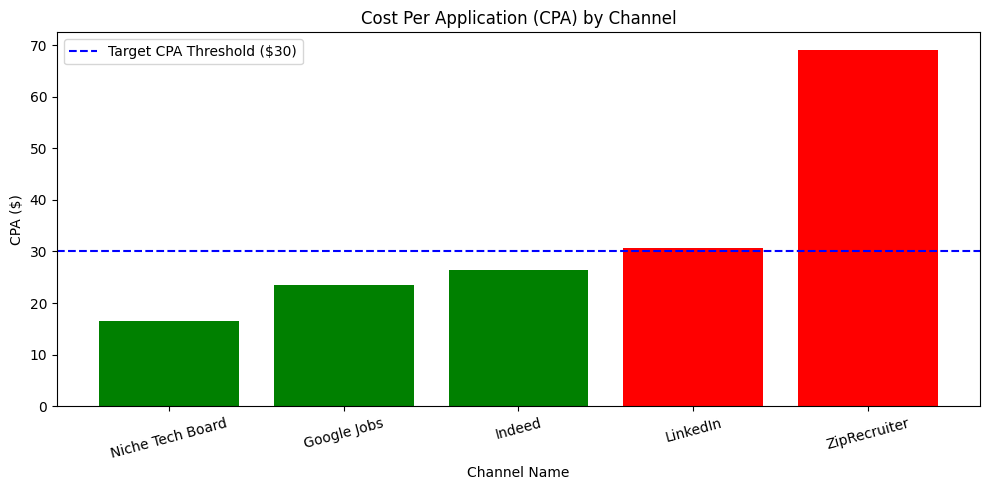

In [ ]:
import matplotlib.pyplot as plt

# Set up the plot style
plt.figure(figsize=(10, 5))
plt.bar(channel_performance["channel_name"], channel_performance["CPA"], color=['green' if c < 30 else 'red' for c in channel_performance["CPA"]])
plt.axhline(y=30, color='blue', linestyle='--', label='Target CPA Threshold ($30)')

plt.title("Cost Per Application (CPA) by Channel")
plt.xlabel("Channel Name")
plt.ylabel("CPA ($)")
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Let's simulate a total monthly budget of $200,000 distributed across channels before vs. after optimization

# 1. BEFORE OPTIMIZATION: Even split or historical spend distribution
total_budget = 200000
channel_performance["Initial_Budget_Share"] = channel_performance["ad_spend"] / channel_performance["ad_spend"].sum()
channel_performance["Initial_Allocated_Spend"] = total_budget * channel_performance["Initial_Budget_Share"]
channel_performance["Initial_Estimated_Hires"] = channel_performance["Initial_Allocated_Spend"] / channel_performance["CPA"]

# 2. AFTER OPTIMIZATION: Applying budget cuts (-30% to flagged) and scaling (+30% to winners)
def get_multiplier(action):
    if "CUT" in action:
        return 0.7  # reduce spend by 30%
    elif "SCALE" in action:
        return 1.3 # increase spend by 30%
    else:
        return 1.0 # maintain

optimization_plan["Multiplier"] = optimization_plan["Optimization_Action"].apply(get_multiplier)
# Re-normalize multipliers to keep total budget at $200,000
raw_adjusted = channel_performance["Initial_Allocated_Spend"].values * optimization_plan["Multiplier"].values
normalization_factor = total_budget / raw_adjusted.sum()
channel_performance["Optimized_Allocated_Spend"] = raw_adjusted * normalization_factor

channel_performance["Optimized_Estimated_Hires"] = channel_performance["Optimized_Allocated_Spend"] / channel_performance["CPA"]

# 3. Print the Before vs After Summary
before_total_hires = channel_performance["Initial_Estimated_Hires"].sum()
after_total_hires = channel_performance["Optimized_Estimated_Hires"].sum()

print("=== PROJECT 1: BEFORE VS. AFTER FINANCIAL IMPACT ===")
print(f"Total Budget Managed: ${total_budget:,.2f}")
print(f"Estimated Total Hires BEFORE Optimization: {int(before_total_hires)}")
print(f"Estimated Total Hires AFTER Optimization:  {int(after_total_hires)}")
print(f"Efficiency Gain: +{((after_total_hires - before_total_hires) / before_total_hires) * 100:.1f}% more hires for the exact same budget!")

=== PROJECT 1: BEFORE VS. AFTER FINANCIAL IMPACT ===
Total Budget Managed: $200,000.00
Estimated Total Hires BEFORE Optimization: 6692
Estimated Total Hires AFTER Optimization:  7290
Efficiency Gain: +8.9% more hires for the exact same budget!
